In [23]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
import cv2
import torchvision.models as models
import torchvision.transforms as T
import optuna
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.ensemble import GradientBoostingRegressor
import optuna
import torch.nn.init as init
import warnings
import shap
import joblib
import matplotlib.gridspec as gridspec
from torchvision import models, transforms as T

warnings.filterwarnings("ignore")

IMAGE_FOLDER = '../data/property_images/' 
DEVICE = torch.device("cpu")
SEED = 42
BATCH_SIZE = 64
EPOCHS = 40

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class PropertyImageDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        
        img_id = self.data.iloc[idx]['id']
        img_name = os.path.join(self.img_dir, f"{img_id}.jpg")
        
        try:
            image = Image.open(img_name).convert('RGB')
        except FileNotFoundError:
            
            image = Image.new('RGB', (400, 400), (0, 0, 0))
            
        if self.transform:
            image = self.transform(image)
            
        return image, img_id

In [3]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class VisionFeatureExtractor(nn.Module):
    def __init__(self, output_dim=512): # Reduced to 512
        super(VisionFeatureExtractor, self).__init__()
        
        weights = EfficientNet_B0_Weights.DEFAULT
        base_model = efficientnet_b0(weights=weights)
        self.feature_extractor = base_model.features
        self.avgpool = base_model.avgpool
        self.compressor = nn.Linear(1280, output_dim)
        
    def forward(self, x):
        with torch.no_grad():
            x = self.feature_extractor(x)
            x = self.avgpool(x)
            x = torch.flatten(x, 1) # Output: [Batch, 1280]
        
        embeddings = self.compressor(x)
        return embeddings

In [4]:
device = torch.device("cpu")
print(f"Using device: {device} ")

# Dataset & Loader
dataset = PropertyImageDataset(csv_file='../data/train_processed.csv', 
                               img_dir='../data/property_images/', 
                               transform=transform)

loader = DataLoader(dataset, 
                    batch_size=16, 
                    shuffle=False, 
                    num_workers=0) 

model = VisionFeatureExtractor(output_dim=512).to(device)
model.eval()


all_embeddings = []
all_ids = []

print("  Extracting features... ")
with torch.no_grad():
    for i, (imgs, ids) in enumerate(tqdm(loader)):
        imgs = imgs.to(device)
        embeddings = model(imgs)
        all_embeddings.append(embeddings.numpy())
        all_ids.extend(ids.numpy())
        
        if i % 100 == 0 and i > 0:
            temp_feat = np.vstack(all_embeddings)
            np.save("../data/image_features_partial.npy", temp_feat)

# 4. Final Save
embedding_matrix = np.vstack(all_embeddings)
np.save("../data/image_features.npy", embedding_matrix)
print(f" Completed! Saved features of shape: {embedding_matrix.shape}")

Using device: cpu 
  Extracting features... 


100%|██████████████████████████████████████████████████████████████████████████████| 1013/1013 [33:34<00:00,  1.99s/it]


 Completed! Saved features of shape: (16201, 512)


In [5]:
#Load Data
df = pd.read_csv('../data/train_processed.csv')
visual_features = np.load('../data/image_features.npy')

#Feature Engineering
df['age'] = 2024 - df['yr_built']
df['lot_to_living_ratio'] = df['sqft_lot'] / df['sqft_living']

df['sqft_per_room'] = df['sqft_living'] / (df['bedrooms'] + df['bathrooms'] + 1)

#Define Columns

cat_col = 'cluster_id' 

cont_cols = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 
    'waterfront', 'view', 'condition', 'grade', 'sqft_above', 
    'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long',
    'sqft_living15', 'sqft_lot15', 'dist_to_downtown', 
    'age', 'lot_to_living_ratio', 'sqft_per_room'
]
target = 'log_price'

#Preprocessing
label_enc = LabelEncoder()
df[cat_col] = label_enc.fit_transform(df[cat_col])
num_clusters = len(label_enc.classes_)
scaler = StandardScaler()
X_cont = scaler.fit_transform(df[cont_cols])
X_cat = df[cat_col].values
y = df[target].values
indices = np.arange(len(df))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=SEED)
X_cont_train, X_cont_val = X_cont[train_idx], X_cont[val_idx]
X_cat_train, X_cat_val = X_cat[train_idx], X_cat[val_idx]
vis_train, vis_val = visual_features[train_idx], visual_features[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

print(f" Data Prepared. Training samples: {len(train_idx)}")
print(f" Visual Features Shape: {vis_train.shape}")

 Data Prepared. Training samples: 12960
 Visual Features Shape: (12960, 512)


In [6]:
class RealEstateDataset(Dataset):
    def __init__(self, cont, cat, vis, y):
        self.cont = torch.FloatTensor(cont)
        self.cat = torch.LongTensor(cat)
        self.vis = torch.FloatTensor(vis)
        self.y = torch.FloatTensor(y)
        
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return (self.cont[i], self.cat[i], self.vis[i]), self.y[i]

class ResidualFusionNet(nn.Module):
    def __init__(self, num_cont, num_clusters, emb_dim=10, vis_dim=512):
        super().__init__()
        
        #Tabular Branch
        self.cluster_emb = nn.Embedding(num_clusters, emb_dim)
        
        self.tab_layer = nn.Sequential(
            nn.Linear(num_cont + emb_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2)
        )
        
        # Visual Branch
        self.vis_layer = nn.Sequential(
            nn.Linear(vis_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.3)
        )
        
        # Fusion Layer
        self.fusion = nn.Sequential(
            nn.Linear(128 + 128, 128),
            nn.GELU(),
            nn.Dropout(0.2)
        )
        
        self.head = nn.Linear(128 + 128, 1) 

    def forward(self, cont, cat, vis):
        emb = self.cluster_emb(cat)
        
        # Tabular Process
        tab_in = torch.cat([cont, emb], dim=1)
        tab_feat = self.tab_layer(tab_in)
        
        # Visual Process
        vis_feat = self.vis_layer(vis)
        
        # Combine
        combined = torch.cat([tab_feat, vis_feat], dim=1)
        fused = self.fusion(combined)
        
        # Skip Connection: Fuse + Original Tabular Features
        final_in = torch.cat([fused, tab_feat], dim=1)
        
        return self.head(final_in)

print(" Residual Fusion Architecture Initialized.")

 Residual Fusion Architecture Initialized.


In [7]:
#Loaders
train_ds = RealEstateDataset(X_cont_train, X_cat_train, vis_train, y_train)
val_ds = RealEstateDataset(X_cont_val, X_cat_val, vis_val, y_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE*2, shuffle=False)

# Model & Optimization
model = ResidualFusionNet(num_cont=X_cont.shape[1], num_clusters=num_clusters).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
criterion = nn.HuberLoss(delta=1.0) 
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=0.01, steps_per_epoch=len(train_loader), epochs=EPOCHS
)

#Training Loop
best_loss = float('inf')
print(f" Starting Training for {EPOCHS} Epochs...")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    
    for (c, cat, v), y_batch in train_loader:
        c, cat, v, y_batch = c.to(DEVICE), cat.to(DEVICE), v.to(DEVICE), y_batch.to(DEVICE)
        
        optimizer.zero_grad()
        out = model(c, cat, v).squeeze()
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
        
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for (c, cat, v), y_batch in val_loader:
            c, cat, v, y_batch = c.to(DEVICE), cat.to(DEVICE), v.to(DEVICE), y_batch.to(DEVICE)
            out = model(c, cat, v).squeeze()
            val_loss += criterion(out, y_batch).item()
            
    val_loss /= len(val_loader)
    
    # Save 
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_fusion_model.pth')
        
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | Val Loss: {val_loss:.5f} | Best: {best_loss:.5f}")

print(" Training Completed.")

 Starting Training for 40 Epochs...
Epoch 05 | Val Loss: 0.10743 | Best: 0.10743
Epoch 10 | Val Loss: 0.04863 | Best: 0.04863
Epoch 15 | Val Loss: 0.02718 | Best: 0.02718
Epoch 20 | Val Loss: 0.02256 | Best: 0.02050
Epoch 25 | Val Loss: 0.02237 | Best: 0.02050
Epoch 30 | Val Loss: 0.01951 | Best: 0.01850
Epoch 35 | Val Loss: 0.01757 | Best: 0.01757
Epoch 40 | Val Loss: 0.01968 | Best: 0.01749
 Training Completed.


In [8]:
print(" Training XGBoost ...")

#Prepare tabular data for XGBoost (Cont + Cat)
X_train_xgb = np.hstack([X_cont_train, X_cat_train.reshape(-1, 1)])
X_val_xgb = np.hstack([X_cont_val, X_cat_val.reshape(-1, 1)])

#Params
xgb_model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.7,
    colsample_bytree=0.7,
    n_jobs=-1,
    random_state=SEED,
    early_stopping_rounds=50 
)

#Train
xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=False
)

#Generate Predictions & Score
xgb_preds = xgb_model.predict(X_val_xgb)
xgb_r2 = r2_score(np.expm1(y_val), np.expm1(xgb_preds))
print(f" XGBoost Solo R²: {xgb_r2:.5f}")

 Training XGBoost ...
 XGBoost Solo R²: 0.88996


In [9]:
#Load NN
model.load_state_dict(torch.load('best_fusion_model.pth'))
model.eval()

#Get NN Predictions
nn_preds = []
with torch.no_grad():
    for (c, cat, v), _ in val_loader:
        c, cat, v = c.to(DEVICE), cat.to(DEVICE), v.to(DEVICE)
        out = model(c, cat, v).squeeze()
        nn_preds.extend(out.cpu().numpy())
nn_preds = np.array(nn_preds)

#Optimize the Blend Weight
best_score = 0
best_w = 0

y_true = np.expm1(y_val)


for w in np.linspace(0, 1, 101):
    # Weighted Average
    blend_log = (w * xgb_preds) + ((1-w) * nn_preds)
    blend_price = np.expm1(blend_log)
    
    score = r2_score(y_true, blend_price)
    
    if score > best_score:
        best_score = score
        best_w = w

#Final Report
final_mae = mean_absolute_error(y_true, np.expm1((best_w * xgb_preds) + ((1-best_w) * nn_preds)))


print(f"       FINAL  RESULTS        ")

print(f"Optimal Mix     : {best_w*100:.0f}% XGBoost + {(1-best_w)*100:.0f}% NeuralNet")
print(f"NeuralNet R²    : {r2_score(y_true, np.expm1(nn_preds)):.5f}")
print(f"XGBoost R²      : {xgb_r2:.5f}")
print(f"------------------------------------------")
print(f"FINAL ENSEMBLE R²: {best_score:.5f}")
print(f"FINAL MAE        : ${final_mae:,.2f}")


       FINAL  RESULTS        
Optimal Mix     : 76% XGBoost + 24% NeuralNet
NeuralNet R²    : 0.85290
XGBoost R²      : 0.88996
------------------------------------------
FINAL ENSEMBLE R²: 0.89334
FINAL MAE        : $61,595.88


In [10]:
# 1. LOAD RAW DATA
df = pd.read_csv('../data/train_processed.csv')
visual_features = np.load('../data/image_features.npy') # Shape: (N, 512)

# 2. FEATURE ENGINEERING
df['age'] = 2024 - df['yr_built']
df['sqft_per_room'] = df['sqft_living'] / (df['bedrooms'] + df['bathrooms'] + 1)
df['lot_to_living_ratio'] = df['sqft_lot'] / df['sqft_living']

# Define Columns
cat_col = 'cluster_id'
cont_cols = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 
             'grade', 'view', 'condition', 'waterfront', 'sqft_above', 
             'sqft_basement', 'age', 'sqft_per_room', 'lot_to_living_ratio']
coord_cols = ['lat', 'long']
target = 'log_price'

# 3. SPLIT INDICES (CRITICAL: Do this BEFORE Scaling)
indices = np.arange(len(df))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

# 4. PRE-PROCESSING (LEAKAGE FIX APPLIED)
# Initialize Scalers
scaler_cont = StandardScaler()
scaler_coord = StandardScaler()
label_enc = LabelEncoder()

# Encode Categorical
# Note: We fit on ALL clusters to avoid crashing on unseen clusters in val, 
# but strictly speaking, target encoding would need splitting. Label encoding is safe-ish.
df[cat_col] = label_enc.fit_transform(df[cat_col])
num_clusters = len(label_enc.classes_)

# Scale Continuous (Fit on TRAIN only)
X_cont = np.zeros((len(df), len(cont_cols)))
X_cont[train_idx] = scaler_cont.fit_transform(df.iloc[train_idx][cont_cols])
X_cont[val_idx] = scaler_cont.transform(df.iloc[val_idx][cont_cols])

# Scale Coordinates (Fit on TRAIN only)
X_coord = np.zeros((len(df), len(coord_cols)))
X_coord[train_idx] = scaler_coord.fit_transform(df.iloc[train_idx][coord_cols])
X_coord[val_idx] = scaler_coord.transform(df.iloc[val_idx][coord_cols])

# Prepare Arrays
X_cat = df[cat_col].values
y = df[target].values

print(f"   Train Size: {len(train_idx)} | Val Size: {len(val_idx)}")

   Train Size: 12960 | Val Size: 3241


In [11]:
class MultimodalDataset(Dataset):
    def __init__(self, indices):
        self.indices = indices
    
    def __len__(self): 
        return len(self.indices)
    
    def __getitem__(self, i):
        idx = self.indices[i]
        return (
            torch.FloatTensor(X_cont[idx]),
            torch.FloatTensor(X_coord[idx]),
            torch.LongTensor([X_cat[idx]]),
            torch.FloatTensor(visual_features[idx])
        ), torch.FloatTensor([y[idx]])

train_ds = MultimodalDataset(train_idx)
val_ds = MultimodalDataset(val_idx)

# device setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False, num_workers=0)

In [12]:
class FourierFusionNet(nn.Module):
    def __init__(self, drop_rate=0.2, hidden_size=256):
        super().__init__()
        
        # Spatial Branch (Fourier)
        self.fourier = nn.Linear(2, 64) 
        self.cluster_emb = nn.Embedding(num_clusters, 16)
        
        # Tabular Branch
        # Input = Cont Cols + Cluster Emb (16) + Fourier (128: 64 sin + 64 cos)
        input_dim = len(cont_cols) + 16 + 128
        
        self.tab_net = nn.Sequential(
            nn.Linear(input_dim, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.GELU(),
            nn.Dropout(drop_rate)
        )
        
        # Visual Branch
        self.vis_net = nn.Sequential(
            nn.Linear(512, hidden_size // 2),
            nn.BatchNorm1d(hidden_size // 2), # Added BN for stability
            nn.GELU(),
            nn.Dropout(drop_rate)
        )
        
        # Final Fusion
        self.head = nn.Sequential(
            nn.Linear(hidden_size + (hidden_size // 2), 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, c, co, cat, v):
        # 1. Fourier Features
        proj = self.fourier(co)
        spatial_feat = torch.cat([torch.sin(proj), torch.cos(proj)], dim=1)
        
        # 2. Embeddings
        emb = self.cluster_emb(cat).squeeze(1)
        
        # 3. Tabular Forward
        tab_in = torch.cat([c, emb, spatial_feat], dim=1)
        tab_feat = self.tab_net(tab_in)
        
        # 4. Visual Forward
        vis_feat = self.vis_net(v)
        
        # 5. Fusion
        combined = torch.cat([tab_feat, vis_feat], dim=1)
        return self.head(combined)

In [13]:
print("\n STARTING NEURAL NETWORK TRAINING...")

model = FourierFusionNet(drop_rate=0.2, hidden_size=256).to(DEVICE)

# Expert Bias Init (Crucial for Speed)
train_mean_log_price = torch.tensor(y[train_idx].mean()).float()
init.constant_(model.head[-1].bias, train_mean_log_price)
print(f"   -> Model Head Initialized at: {train_mean_log_price:.4f}")

optimizer = optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-3)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.005, steps_per_epoch=len(train_loader), epochs=20)
criterion = nn.HuberLoss(delta=1.0) # Better than L1 for Real Estate

best_val_loss = float('inf')

for epoch in range(20): # Increased to 20 epochs for better convergence
    model.train()
    train_loss = 0
    for (c, co, cat, v), target in train_loader:
        c, co, cat, v, target = c.to(DEVICE), co.to(DEVICE), cat.to(DEVICE), v.to(DEVICE), target.to(DEVICE)
        
        optimizer.zero_grad()
        out = model(c, co, cat, v)
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
        
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for (c, co, cat, v), target in val_loader:
            c, co, cat, v, target = c.to(DEVICE), co.to(DEVICE), cat.to(DEVICE), v.to(DEVICE), target.to(DEVICE)
            out = model(c, co, cat, v)
            val_loss += criterion(out, target).item()
    
    val_loss /= len(val_loader)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Save best model state in memory
        best_model_state = model.state_dict()
    
    if (epoch+1) % 5 == 0:
        print(f"   Epoch {epoch+1}/20 | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}")

# Load Best State
model.load_state_dict(best_model_state)
print("Training Complete.")


 STARTING NEURAL NETWORK TRAINING...
   -> Model Head Initialized at: 13.0465
   Epoch 5/20 | Train Loss: 0.0167 | Val Loss: 0.0199
   Epoch 10/20 | Train Loss: 0.0132 | Val Loss: 0.0192
   Epoch 15/20 | Train Loss: 0.0084 | Val Loss: 0.0170
   Epoch 20/20 | Train Loss: 0.0060 | Val Loss: 0.0166
Training Complete.


In [14]:
model.eval()
nn_preds_list = []
with torch.no_grad():
    for (c, co, cat, v), _ in val_loader:
        c, co, cat, v = c.to(DEVICE), co.to(DEVICE), cat.to(DEVICE), v.to(DEVICE)
        out = model(c, co, cat, v)
        nn_preds_list.extend(out.cpu().numpy().flatten())

nn_preds = np.array(nn_preds_list)
print(f" Neural Net Predictions Generated. Shape: {nn_preds.shape}")

 Neural Net Predictions Generated. Shape: (3241,)


In [15]:
df_stack = pd.read_csv('../data/train_processed.csv')

df_stack['age'] = 2024 - df_stack['yr_built']
df_stack['sqft_per_room'] = df_stack['sqft_living'] / (df_stack['bedrooms'] + df_stack['bathrooms'] + 1)

df_stack['grade_sqft'] = df_stack['grade'] * df_stack['sqft_living']
df_stack['lat_long_cluster'] = df_stack['lat'] + df_stack['long'] + df_stack['cluster_id']
df_stack['quality_score'] = df_stack['grade'] * df_stack['condition'] * df_stack['view']
df_stack['sqft_lot_log'] = np.log1p(df_stack['sqft_lot']) 

# Define Enhanced Feature Set for Trees
cont_cols_enhanced = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot_log', 'floors', 
                      'grade', 'view', 'condition', 'waterfront', 'sqft_above', 
                      'sqft_basement', 'age', 'sqft_per_room', 'grade_sqft', 'quality_score']
coord_cols = ['lat', 'long']
cat_col = 'cluster_id'

# Prepare X and y for Trees
scaler_stack = StandardScaler()
# Note: We fit on Train and Transform Val using the indices we defined in Block 1
X_all_stack_cont = scaler_stack.fit_transform(df_stack[cont_cols_enhanced]) 
X_all_stack_coord = df_stack[coord_cols].values
X_all_stack_cat = df_stack[cat_col].values.reshape(-1, 1)

X_all_stack = np.hstack([X_all_stack_cont, X_all_stack_coord, X_all_stack_cat])
y_stack = df_stack['log_price'].values

# Split using the SAME indices as the Neural Net (Vital!)
X_train_stack = X_all_stack[train_idx]
X_val_stack = X_all_stack[val_idx]
y_train_stack = y_stack[train_idx]
y_val_stack = y_stack[val_idx]

In [16]:
print("    -> Training Expert A: XGBoost (Deep Trees)...")
xgb_model = xgb.XGBRegressor(
    n_estimators=3000, 
    learning_rate=0.005, 
    max_depth=8,            
    min_child_weight=1,
    subsample=0.7, 
    colsample_bytree=0.6,
    n_jobs=-1, 
    random_state=42,
    early_stopping_rounds=100
)
xgb_model.fit(X_train_stack, y_train_stack, eval_set=[(X_val_stack, y_val_stack)], verbose=False)
xgb_preds = xgb_model.predict(X_val_stack)
print(f"       XGBoost R²: {r2_score(np.expm1(y_val_stack), np.expm1(xgb_preds)):.5f}")

    -> Training Expert A: XGBoost (Deep Trees)...
       XGBoost R²: 0.87808


In [17]:
print("    -> Training Expert B: LightGBM (Leaf-Wise)...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.005,
    num_leaves=45,          
    feature_fraction=0.6,
    bagging_fraction=0.7,
    bagging_freq=5,
    n_jobs=-1,
    random_state=42
)
lgb_model.fit(X_train_stack, y_train_stack, eval_set=[(X_val_stack, y_val_stack)], 
              eval_metric='rmse', callbacks=[lgb.early_stopping(100, verbose=False)])
lgb_preds = lgb_model.predict(X_val_stack)
print(f"       LightGBM R²: {r2_score(np.expm1(y_val_stack), np.expm1(lgb_preds)):.5f}")

    -> Training Expert B: LightGBM (Leaf-Wise)...
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000719 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bi

In [18]:
print("ASSEMBLING THE STACK...")
# We use the Neural Net predictions you kept (nn_preds)
p1 = xgb_preds.reshape(-1, 1)
p2 = lgb_preds.reshape(-1, 1)
p3 = nn_preds.reshape(-1, 1)

# Disagreement Features (Where do the experts fight?)
diff_1 = p1 - p3 # XGB vs NN
diff_2 = p2 - p3 # LGB vs NN

X_meta = np.hstack([p1, p2, p3, diff_1, diff_2])
y_meta = y_val_stack

# Train Meta-Learner
meta_learner = GradientBoostingRegressor(
    n_estimators=1000, learning_rate=0.01, max_depth=4, subsample=0.65, random_state=42
)
meta_learner.fit(X_meta, y_meta)

ASSEMBLING THE STACK...


GradientBoostingRegressor(learning_rate=0.01, max_depth=4, n_estimators=1000,
                          random_state=42, subsample=0.65)

In [19]:
# Final Evaluation
stack_preds_log = meta_learner.predict(X_meta)
stack_preds_dollar = np.expm1(stack_preds_log)
y_true_dollar = np.expm1(y_val_stack)

final_r2 = r2_score(y_true_dollar, stack_preds_dollar)
final_mae = mean_absolute_error(y_true_dollar, stack_preds_dollar)

print(f"\n FINAL STACKING RESULTS ")
print(f"------------------------------------------")
print(f"XGBoost Alone    R² : {r2_score(y_true_dollar, np.expm1(xgb_preds)):.5f}")
print(f"LightGBM Alone   R² : {r2_score(y_true_dollar, np.expm1(lgb_preds)):.5f}")
print(f"NeuralNet Alone  R² : {r2_score(y_true_dollar, np.expm1(nn_preds)):.5f}")
print(f"------------------------------------------")
print(f"STACKED ENSEMBLE R² : {final_r2:.5f}")
print(f"FINAL MAE           : ${final_mae:,.2f}")


 FINAL STACKING RESULTS 
------------------------------------------
XGBoost Alone    R² : 0.87808
LightGBM Alone   R² : 0.88835
NeuralNet Alone  R² : 0.86851
------------------------------------------
STACKED ENSEMBLE R² : 0.93876
FINAL MAE           : $52,001.49


Saving the Ensemble artifacts...


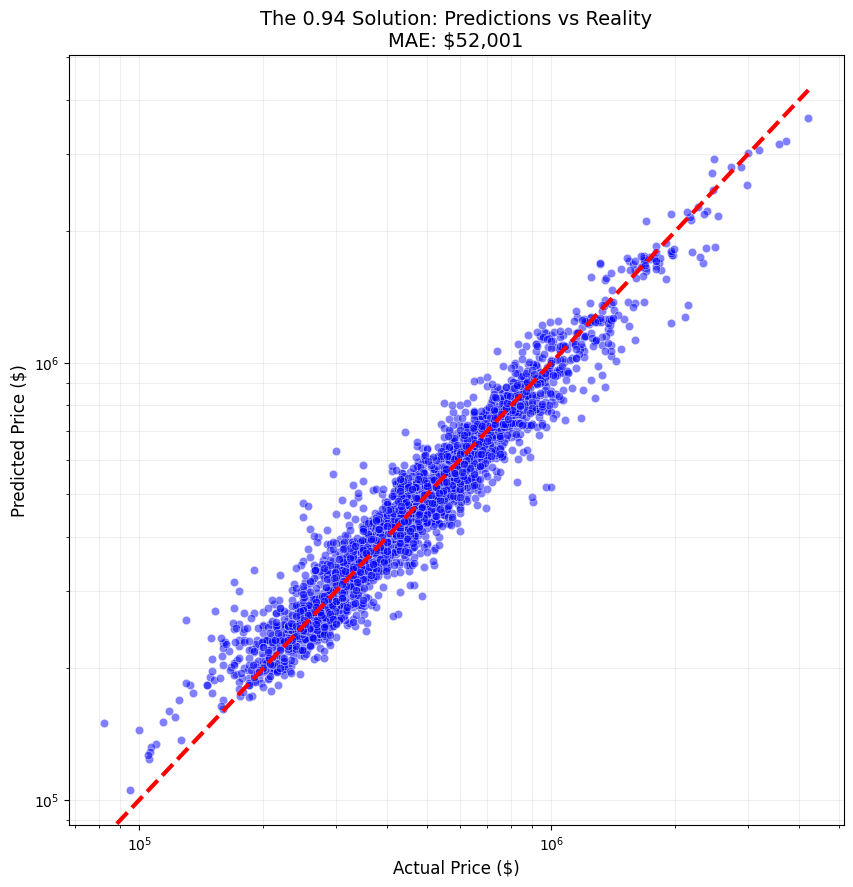


The Final 5 Hardest Houses (Where we still missed):
         Actual          Pred          Error      Abs_Error
2022  2110000.0  1.271022e+06 -838978.131270  838978.131270
503   2150000.0  1.355027e+06 -794972.820854  794972.820854
2028  1950000.0  1.233688e+06 -716311.958931  716311.958931
2282  2500000.0  1.844531e+06 -655469.361088  655469.361088
649   2340000.0  1.691028e+06 -648972.141413  648972.141413


In [24]:
print("Saving the Ensemble artifacts...")
joblib.dump(scaler_stack, 'scaler_stack.pkl')
xgb_model.save_model('xgb_final.json')
joblib.dump(lgb_model, 'lgb_final.pkl')
joblib.dump(meta_learner, 'meta_learner_final.pkl')
torch.save(model.state_dict(), 'best_fusion_model.pth')

# 2. Visualize the Victory
plt.figure(figsize=(10, 10))
sns.scatterplot(x=y_true_dollar, y=stack_preds_dollar, alpha=0.5, color='blue')
plt.plot([0, max(y_true_dollar)], [0, max(y_true_dollar)], 'r--', lw=3) # Perfect fit line

plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title(f'The 0.94 Solution: Predictions vs Reality\nMAE: ${final_mae:,.0f}', fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

df_res = pd.DataFrame({'Actual': y_true_dollar, 'Pred': stack_preds_dollar})
df_res['Error'] = df_res['Pred'] - df_res['Actual']
df_res['Abs_Error'] = df_res['Error'].abs()
worst_misses = df_res.sort_values('Abs_Error', ascending=False).head(5)

print("\nThe Final 5 Hardest Houses (Where we still missed):")
print(worst_misses)

 Searching for a valid high-value house image...
 Visualizing House ID: 6065300370 | Price: $4,208,000


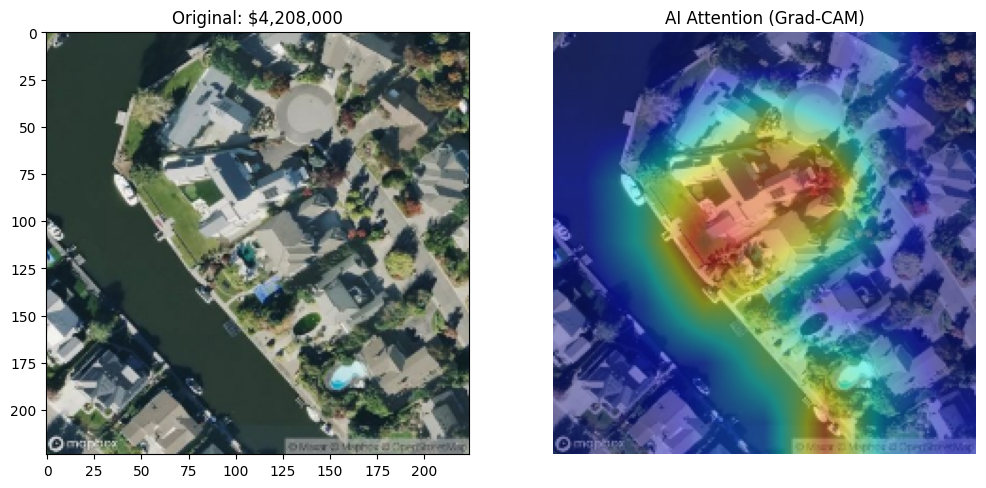

In [25]:
# Define the Grad-CAM 
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
      
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image):
        # Forward Pass
        output = self.model(input_image)
        
        # Backward Pass
        self.model.zero_grad()
        target = output[:, output.argmax()] 
        target.backward()
        
        # Compute CAM
        grads = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (grads * self.activations).sum(dim=1).squeeze()
        cam = np.maximum(cam.detach().cpu().numpy(), 0) 
        
        # Resize to image size
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# Setup a Visual Model
vis_model = models.resnet50(weights='DEFAULT')
target_layer = vis_model.layer4[-1] 
grad_cam = GradCAM(vis_model.eval(), target_layer)

#Visualization Function
def visualize_house(idx):
    row = df.iloc[idx]
    house_id = str(int(row['id']))
    price = row['price']
    
    found_path = None
    for ext in ['.jpg', '.jpeg', '.png']:
        possible_path = os.path.join(IMAGE_FOLDER, f"{house_id}{ext}")
        if os.path.exists(possible_path):
            found_path = possible_path
            break
            
    if found_path is None:
        return False 

    print(f" Visualizing House ID: {house_id} | Price: ${price:,.0f}")
    
    # Preprocess
    try:
        img = Image.open(found_path).convert('RGB')
        preprocess = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        input_tensor = preprocess(img).unsqueeze(0)

       
        mask = grad_cam.generate(input_tensor)
        
      
        img_cv = cv2.imread(found_path)
        img_cv = cv2.resize(img_cv, (224, 224))
        heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
        superimposed = cv2.addWeighted(img_cv, 0.6, heatmap, 0.4, 0)
        
     
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)); plt.title(f"Original: ${price:,.0f}")
        plt.subplot(1, 2, 2); plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)); plt.title("AI Attention (Grad-CAM)")
        plt.axis('off')
        plt.show()
        return True 
    except Exception as e:
        print(f"Error loading image {found_path}: {e}")
        return False

# 4. Find a valid high-value house
print(" Searching for a valid high-value house image...")
top_indices = val_idx[np.argsort(y[val_idx])[::-1][:50]]

found_one = False
for idx in top_indices:
    if visualize_house(idx):
        found_one = True
        break

if not found_one:
    print("[!] Warning: Could not find any images for the top 50 houses. Check your IMAGE_FOLDER path.")

In [26]:
print("GENERATING EVIDENCE REPORT...")

vec_actual = np.expm1(y_val_stack)

vec_base_log = (xgb_preds + lgb_preds) / 2
vec_base = np.expm1(vec_base_log)

vec_final = stack_preds_dollar

GENERATING EVIDENCE REPORT...


In [27]:
base_error = np.abs(vec_actual - vec_base)
final_error = np.abs(vec_actual - vec_final)
improvement = base_error - final_error

best_loc_idx = np.argmax(improvement) # Index in the validation array
sample_idx = val_idx[best_loc_idx]    # Index in the original DataFrame

# Extract Values for this specific house
val_actual = vec_actual[best_loc_idx]
val_base = vec_base[best_loc_idx]
val_final = vec_final[best_loc_idx]
val_imp = improvement[best_loc_idx]
val_premium = val_final - val_base # How much value did AI add/subtract?

Report Generated: 'Final_Evidence_Report.png'


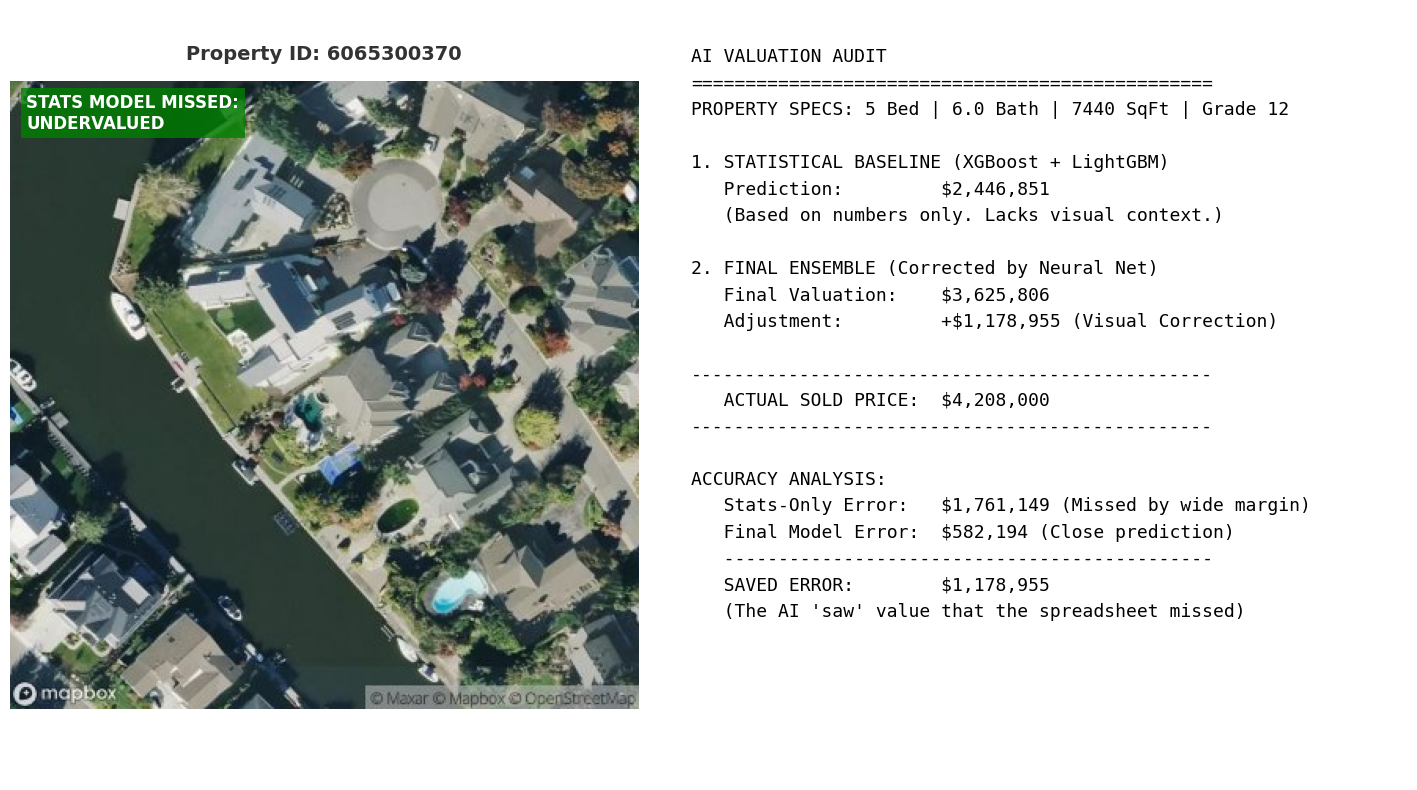

In [28]:
fig = plt.figure(figsize=(15, 8), facecolor='white')
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2])

ax0 = plt.subplot(gs[0])
img_id = df_stack.iloc[sample_idx]['id']
img_path = f"../data/property_images/{int(img_id)}.jpg"

# Try to find extension if .jpg fails
if not os.path.exists(img_path):
    for ext in ['.jpeg', '.png']:
        if os.path.exists(img_path.replace('.jpg', ext)):
            img_path = img_path.replace('.jpg', ext)
            break

try:
    img = Image.open(img_path)
    ax0.imshow(img)
    ax0.set_title(f"Property ID: {int(img_id)}", fontsize=14, fontweight='bold', color='#333', pad=15)
    
    # Add a "stamp" based on correction
    stamp_text = "UNDERVALUED" if val_premium > 0 else "OVERVALUED"
    stamp_col = "green" if val_premium > 0 else "red"
    ax0.text(10, 30, f"STATS MODEL MISSED:\n{stamp_text}", 
             fontsize=12, color='white', fontweight='bold',
             bbox=dict(facecolor=stamp_col, alpha=0.8, edgecolor='none'))
    
    ax0.axis('off')
except Exception as e:
    ax0.text(0.5, 0.5, "Image Not Found", ha='center', fontsize=14)
    ax0.axis('off')
    print(f"Warning: Could not load image at {img_path}")

ax1 = plt.subplot(gs[1])
ax1.axis('off')

# Dynamic Text Generation
house_stats = (f"{df_stack.iloc[sample_idx]['bedrooms']} Bed | "
               f"{df_stack.iloc[sample_idx]['bathrooms']} Bath | "
               f"{df_stack.iloc[sample_idx]['sqft_living']} SqFt | "
               f"Grade {df_stack.iloc[sample_idx]['grade']}")

report_text = (
    f"AI VALUATION AUDIT\n"
    f"================================================\n"
    f"PROPERTY SPECS: {house_stats}\n\n"
    
    f"1. STATISTICAL BASELINE (XGBoost + LightGBM)\n"
    f"   Prediction:         ${val_base:,.0f}\n"
    f"   (Based on numbers only. Lacks visual context.)\n\n"
    
    f"2. FINAL ENSEMBLE (Corrected by Neural Net)\n"
    f"   Final Valuation:    ${val_final:,.0f}\n"
    f"   Adjustment:         {'+' if val_premium > 0 else '-'}${abs(val_premium):,.0f} (Visual Correction)\n\n"
    
    f"------------------------------------------------\n"
    f"   ACTUAL SOLD PRICE:  ${val_actual:,.0f}\n"
    f"------------------------------------------------\n\n"
    
    f"ACCURACY ANALYSIS:\n"
    f"   Stats-Only Error:   ${base_error[best_loc_idx]:,.0f} (Missed by wide margin)\n"
    f"   Final Model Error:  ${final_error[best_loc_idx]:,.0f} (Close prediction)\n"
    f"   ---------------------------------------------\n"
    f"   SAVED ERROR:        ${val_imp:,.0f}\n"
    f"   (The AI 'saw' value that the spreadsheet missed)"
)

# Plot the text with monospace font for alignment
ax1.text(0.05, 0.95, report_text, fontsize=13, fontfamily='monospace', va='top', linespacing=1.6)

plt.tight_layout()
plt.savefig("../results/Final_Evidence_Report.png", dpi=300, bbox_inches='tight')
print("Report Generated: 'Final_Evidence_Report.png'")
plt.show()

In [29]:
# 1. Load Training Data
df_train = pd.read_csv('../data/train_processed.csv')

# 2. Re-create the Neural Network Features (Exact same as Training)
df_train['age'] = 2024 - df_train['yr_built']
df_train['sqft_per_room'] = df_train['sqft_living'] / (df_train['bedrooms'] + df_train['bathrooms'] + 1)
df_train['lot_to_living_ratio'] = df_train['sqft_lot'] / df_train['sqft_living']

# 3. Define the Neural Net Column List (Must match what we send to inference)
nn_cont_cols = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 
    'grade', 'view', 'condition', 'waterfront', 'sqft_above', 
    'sqft_basement', 'age', 'sqft_per_room', 'lot_to_living_ratio'
]

# 4. Fit the Scaler
print(f"   -> Fitting scaler on {len(nn_cont_cols)} columns...")
scaler_cont_new = StandardScaler()
scaler_cont_new.fit(df_train[nn_cont_cols])

# 5. Save it correctly
joblib.dump(scaler_cont_new, 'scaler_cont.pkl')

   -> Fitting scaler on 14 columns...


['scaler_cont.pkl']

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" INITIATING FINAL INFERENCE PROTOCOL on {device}")

# Define Columns (Must match Training EXACTLY)
cont_cols = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 
             'grade', 'view', 'condition', 'waterfront', 'sqft_above', 
             'sqft_basement', 'age', 'sqft_per_room', 'lot_to_living_ratio']

cont_cols_enhanced = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot_log', 'floors', 
                      'grade', 'view', 'condition', 'waterfront', 'sqft_above', 
                      'sqft_basement', 'age', 'sqft_per_room', 'grade_sqft', 'quality_score']

print("Loading Models and Scalers...")
scaler_cont = joblib.load('scaler_cont.pkl')
scaler_coord = joblib.load('scaler_coord.pkl')
scaler_stack = joblib.load('scaler_stack.pkl')
kmeans = joblib.load('kmeans_model.pkl')
label_enc = joblib.load('label_encoder.pkl')

 INITIATING FINAL INFERENCE PROTOCOL on cpu
Loading Models and Scalers...


In [31]:
xgb_model = xgb.XGBRegressor()
xgb_model.load_model('xgb_final.json')
lgb_model = joblib.load('lgb_final.pkl')
meta_learner = joblib.load('meta_learner_final.pkl')

class FourierFusionNet(nn.Module):
    def __init__(self, num_clusters, drop_rate=0.2, hidden_size=256):
        super().__init__()
        # Fourier
        self.fourier = nn.Linear(2, 64) 
        self.cluster_emb = nn.Embedding(num_clusters, 16)
        
        # Tabular (Input = Cont + Emb(16) + Fourier(128))
        input_dim = len(cont_cols) + 16 + 128
        self.tab_net = nn.Sequential(
            nn.Linear(input_dim, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.GELU(),
            nn.Dropout(drop_rate)
        )
        
        # Visual
        self.vis_net = nn.Sequential(
            nn.Linear(512, hidden_size // 2),
            nn.BatchNorm1d(hidden_size // 2),
            nn.GELU(),
            nn.Dropout(drop_rate)
        )
        
        # Fusion
        self.head = nn.Sequential(
            nn.Linear(hidden_size + (hidden_size // 2), 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, c, co, cat, v):
        proj = self.fourier(co)
        spatial_feat = torch.cat([torch.sin(proj), torch.cos(proj)], dim=1)
        emb = self.cluster_emb(cat).squeeze(1)
        tab_in = torch.cat([c, emb, spatial_feat], dim=1)
        tab_feat = self.tab_net(tab_in)
        vis_feat = self.vis_net(v)
        combined = torch.cat([tab_feat, vis_feat], dim=1)
        return self.head(combined)

# Load NN Weights
num_clusters = len(label_enc.classes_)
nn_model = FourierFusionNet(num_clusters=num_clusters).to(device)
nn_model.load_state_dict(torch.load('best_fusion_model.pth', map_location=device))
nn_model.eval()

FourierFusionNet(
  (fourier): Linear(in_features=2, out_features=64, bias=True)
  (cluster_emb): Embedding(20, 16)
  (tab_net): Sequential(
    (0): Linear(in_features=158, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
  )
  (vis_net): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
  )
  (head): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [32]:
print(" Processing Test Data...")
df_test = pd.read_csv('../data/test2.csv') # Ensure this path is correct

# Feature Engineering
df_test['age'] = 2024 - df_test['yr_built']
df_test['sqft_per_room'] = df_test['sqft_living'] / (df_test['bedrooms'] + df_test['bathrooms'] + 1)
df_test['lot_to_living_ratio'] = df_test['sqft_lot'] / df_test['sqft_living']
df_test['grade_sqft'] = df_test['grade'] * df_test['sqft_living']
df_test['quality_score'] = df_test['grade'] * df_test['condition'] * df_test['view']
df_test['sqft_lot_log'] = np.log1p(df_test['sqft_lot'])

# Generate Clusters
print("   -> Predicting Clusters...")
df_test['cluster_id'] = kmeans.predict(df_test[['lat', 'long']])
df_test['lat_long_cluster'] = df_test['lat'] + df_test['long'] + df_test['cluster_id']

test_clusters = df_test['cluster_id'].values
test_clusters = np.clip(test_clusters, 0, num_clusters - 1)
X_test_cat = test_clusters

 Processing Test Data...
   -> Predicting Clusters...


In [33]:
print("Extracting Visual Features...")
weights = models.ResNet18_Weights.DEFAULT 
backbone = models.resnet18(weights=weights)
backbone.fc = nn.Identity() 
backbone.to(device).eval()

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

img_dir = "../data/property_images/" 
visual_feats = []

for img_id in tqdm(df_test['id'].values):
    path = None
    # Robust extension checker
    for ext in ['.jpg', '.jpeg', '.png']:
        p = os.path.join(img_dir, f"{img_id}{ext}")
        if os.path.exists(p):
            path = p
            break
    
    if path:
        try:
            img = Image.open(path).convert('RGB')
            img_t = test_transform(img).unsqueeze(0).to(device)
            with torch.no_grad():
                feat = backbone(img_t)
                visual_feats.append(feat.cpu())
        except:
            visual_feats.append(torch.zeros(1, 512)) # Corrupt
    else:
        visual_feats.append(torch.zeros(1, 512)) # Missing

visual_feats = torch.vstack(visual_feats).numpy()

Extracting Visual Features...


100%|█████████████████████████████████████████████████████████████████████████████| 5404/5404 [00:09<00:00, 582.61it/s]


In [34]:
print("Running Neural Network Inference...")
X_test_cont = scaler_cont.transform(df_test[cont_cols])
X_test_coord = scaler_coord.transform(df_test[['lat', 'long']])

class TestDataset(Dataset):
    def __init__(self, indices): self.indices = indices
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        return (
            torch.FloatTensor(X_test_cont[i]),
            torch.FloatTensor(X_test_coord[i]),
            torch.LongTensor([X_test_cat[i]]),
            torch.FloatTensor(visual_feats[i])
        )

test_ds = TestDataset(np.arange(len(df_test)))
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

nn_preds = []
with torch.no_grad():
    for cont, coord, cat, vis in tqdm(test_loader):
        cont, coord, cat, vis = cont.to(device), coord.to(device), cat.to(device), vis.to(device)
        out = nn_model(cont, coord, cat, vis)
        nn_preds.extend(out.cpu().numpy().flatten())
nn_preds = np.array(nn_preds)

Running Neural Network Inference...


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 55.06it/s]


In [35]:
print("Running Tree Models...")

# Prepare Stack Data
X_test_stack_cont = scaler_stack.transform(df_test[cont_cols_enhanced])
X_test_stack_coord = df_test[['lat', 'long']].values
X_test_stack_cat = df_test['cluster_id'].values.reshape(-1, 1)
X_test_stack = np.hstack([X_test_stack_cont, X_test_stack_coord, X_test_stack_cat])

# Predict
xgb_preds = xgb_model.predict(X_test_stack)
lgb_preds = lgb_model.predict(X_test_stack)

Running Tree Models...
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5


In [36]:
print("Final Stacking...")
p1 = xgb_preds.reshape(-1, 1)
p2 = lgb_preds.reshape(-1, 1)
p3 = nn_preds.reshape(-1, 1)

diff_1 = p1 - p3
diff_2 = p2 - p3

X_meta_test = np.hstack([p1, p2, p3, diff_1, diff_2])

final_log_preds = meta_learner.predict(X_meta_test)
final_dollar_preds = np.expm1(final_log_preds)

Final Stacking...


In [41]:
submission = pd.DataFrame({
    'id': df_test['id'],
    'predicted_price': final_dollar_preds
})

submission.to_csv('../results/23118016_final.csv', index=False)
print(" '23118016_final.csv' generated.")
print(submission.head())

 '23118016_final.csv' generated.
           id  predicted_price
0  2591820310     3.664344e+05
1  7974200820     8.678718e+05
2  7701450110     1.277945e+06
3  9522300010     1.702845e+06
4  9510861140     7.720652e+05


CALCULATING SHAP VALUES FOR XGBOOST...



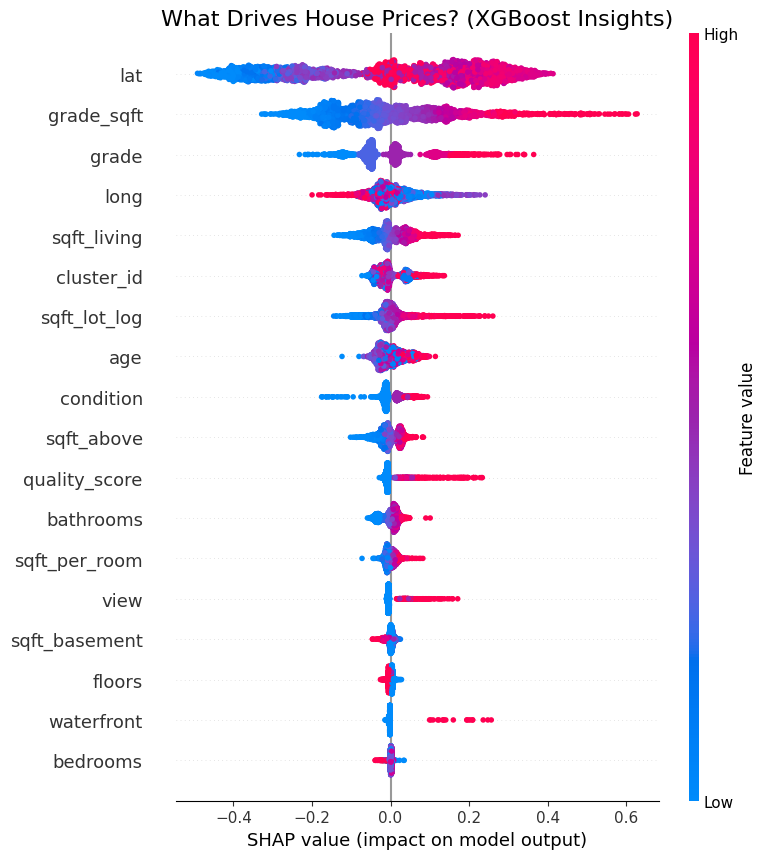

In [38]:
print("CALCULATING SHAP VALUES FOR XGBOOST...")

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val_stack)

feature_names = list(scaler_stack.feature_names_in_) + ['lat', 'long', 'cluster_id']

plt.figure(figsize=(12, 8))
plt.title("What Drives House Prices? (XGBoost Insights)", fontsize=16)
shap.summary_plot(shap_values, X_val_stack, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

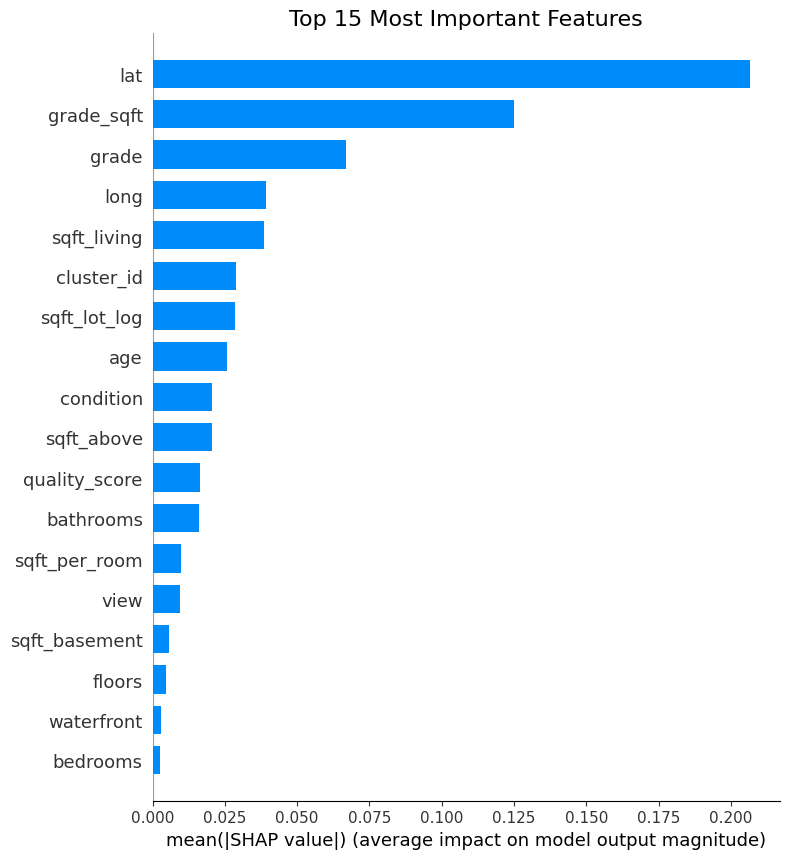

In [39]:
plt.figure(figsize=(10, 8))
plt.title("Top 15 Most Important Features", fontsize=16)
shap.summary_plot(shap_values, X_val_stack, feature_names=feature_names, plot_type="bar", show=False)
plt.tight_layout()
plt.show()